In [1]:
from trainModel import trainModel
from Dataset import ModelDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, confusion_matrix, accuracy_score, precision_recall_curve
import pandas as pd
import os
from generateSplits import generateSplits
from torch.utils.data import DataLoader
import torch,gc
import numpy as np
from typing import Literal, Callable, Iterator
from functools import partial
import matplotlib.pyplot as plt

In [2]:
best_params = {'lr': 0.010203264127576701, 'weight_decay': 0.004617603477095672, 'batch_size': 8, 'optimiser_name': 'Adam'}

In [3]:
DATASET_PATH = r"E:\SRP\SRP-2025-Project\ISPY2_T0_T3_DCE_npz"
MODEL_SAVE_PATH = r"E:\SRP\SRP-2025-Project\model_weights"

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
dataset_df = pd.read_excel(r"e:\SRP\ISPY2-Data-Collector\ISPY2-Imaging-Cohort-1-Clinical-Data.xlsx")
dataset_df = dataset_df.set_index("Patient_ID",drop=True)
dataset_df = dataset_df.loc[dataset_df.index.isin([int(os.path.splitext(fname)[0].replace("ISPY2-","")) for fname in os.listdir(DATASET_PATH)]),["HR","HER2","pCR"]]

train_df, test_df = generateSplits(dataset_df,0.2,seed=2008)
skf = StratifiedKFold(n_splits=4,shuffle=True,random_state=2008)

# Optional: Delete if too slow
train_dataset = ModelDataset(train_df,DATASET_PATH,{0:1,1:2},loading_bar=True)
train_loader = DataLoader(train_dataset,batch_size=best_params["batch_size"],shuffle=True)
test_dataset = ModelDataset(test_df, DATASET_PATH, {0:1,1:1}, loading_bar=True)
test_loader =DataLoader(test_dataset, batch_size=best_params["batch_size"])



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 342/342 [05:14<00:00,  1.09it/s]


Dataset initialised with 463 entries.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:42<00:00,  2.01it/s]


Dataset initialised with 86 entries.


In [4]:
def get_scores(model:torch.nn.Module,test_loader:DataLoader,combine_timepoints:bool,out_features:Literal[1,2],mode:Literal["preNac","both"]="preNac"):
    model.eval()
    y_true=[]
    y_score=[]
    
    with torch.no_grad():
        for T0_volumes,T3_volumes,mols,labels in test_loader:
            T0_volumes = T0_volumes.to(device)
            T3_volumes = T3_volumes.to(device)
            mols = mols.to(device)
            labels = labels.to(device)
            if combine_timepoints:
                logits = model(torch.cat((T0_volumes,T3_volumes),dim=1),mols,mode)
            else:
                logits = model(T0_volumes,T3_volumes,mols,mode)
                
            if out_features == 1:
                score = torch.sigmoid(logits).squeeze()
            elif out_features == 2:
                score = torch.nn.functional.softmax(logits,dim=1)[:,1]
            y_true.extend(labels.cpu().numpy())
            y_score.extend(score.cpu().numpy())
    return y_true,y_score

def score_to_pred(y_true,y_score):
    fpr,tpr,thresholds = roc_curve(y_true,y_score)
    youden_index = tpr-fpr
    best_idx = np.argmax(youden_index)
    best_threshold = thresholds[best_idx]
    y_pred = np.array(y_score)>=best_threshold
    return y_pred

In [5]:
def evaluate_roc_auc(model:torch.nn.Module,test_loader:DataLoader,combine_timepoints:bool,out_features:Literal[1,2],testKwargs:dict):
    model.eval()
    y_true=[]
    y_score=[]
    
    with torch.no_grad():
        for T0_volumes,T3_volumes,mols,labels in test_loader:
            T0_volumes = T0_volumes.to(device)
            T3_volumes = T3_volumes.to(device)
            mols = mols.to(device)
            labels = labels.to(device)
            if combine_timepoints:
                logits = model(torch.cat((T0_volumes,T3_volumes),dim=1),mols,**testKwargs)
            else:
                logits = model(T0_volumes,T3_volumes,mols,**testKwargs)
                
            if out_features == 1:
                score = torch.sigmoid(logits).squeeze()
            elif out_features == 2:
                score = torch.nn.functional.softmax(logits,dim=1)[:,1]
            y_true.extend(labels.cpu().numpy())
            y_score.extend(score.cpu().numpy())
    return float(roc_auc_score(y_true,y_score))

In [6]:
def getTrainedModel(
    model: torch.nn.Module,
    combine_timepoints: bool,
    out_features: Literal[1, 2],
    loss_fn: Callable,
    trainKwargs: dict,
    testKwargs: dict,
    save:bool,
    filename:str,
):
    optimiser_class = partial(
        torch.optim.AdamW,
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"],
    )

    trainedModel, _ = trainModel(
        model=model,
        train_loader=train_loader,
        combine_timepoints=combine_timepoints,
        out_features=out_features,
        loss_fn=loss_fn,
        optimiser=optimiser_class(model.parameters()),
        num_epochs=30,
        val_loader=test_loader,
        score_fn=evaluate_roc_auc,
        score_name="ROC AUC",
        patience=10,
        trainKwargs=trainKwargs,
        testKwargs=testKwargs,
    )
    
    if save:
        torch.save(trainedModel.state_dict(), os.path.join(MODEL_SAVE_PATH, filename))
    
    return trainedModel



In [7]:

def plot(y_true,y_score):
    positive_ratio = sum(y_true)/len(y_true)
    
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)  
    
    # ---- Compute Youden Index ----
    youden = tpr - fpr                      # same as sensitivity + specificity - 1
    best_idx = np.argmax(youden)            # index of best threshold
    best_fpr = fpr[best_idx]
    best_tpr = tpr[best_idx]
    youden_index = roc_thresholds[best_idx]
    
    
    
    plt.figure()
    plt.plot(fpr,tpr)
    plt.plot([0, 1], [0, 1], "--")
    # ---- Mark Youden point ----
    plt.scatter(best_fpr, best_tpr, color="red", s=50, zorder=3,
                label=f"Youden Index\nTPR={best_tpr:.3f}, FPR={best_fpr:.3f}")
    
     # ---- Set ticks at 0.1 increments ----
    plt.xticks(np.arange(0.0, 1.1, 0.1))
    plt.yticks(np.arange(0.0, 1.1, 0.1))
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve\nAUC = {roc_auc_score(y_true,y_score):.3f}")
    plt.grid()
    plt.legend()
    

    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    plt.figure()
    plt.plot(recall,precision)
    plt.axhline(positive_ratio, color="gray", linestyle="--", label=f"Baseline AP = {positive_ratio:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve\nAverage Precision = {average_precision_score(y_true,y_score):.3f}")
    
    y_pred = score_to_pred(y_true,y_score)
    y_signed = np.array([score-youden_index for score in y_score])
    print(sum(y_signed<0))
    # Sort for better visualization
    idx = np.argsort(y_signed)
    y_sorted = np.array(y_signed)[idx]
    labels_sorted = np.array(y_true)[idx]
    # Color by true label: blue = pCR, red = non-pCR
    colors = ["blue" if t==1 else "red" for t in labels_sorted]
    # Plot
    plt.figure(figsize=(24,5))
    plt.bar(range(len(y_sorted)), y_sorted, color=colors, width=0.8)
    plt.ylabel("Predicted Score (positive = pCR, negative = non-pCR)")
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.ylim((1.2*min(y_signed), 1.2*max(y_signed)))
    plt.grid(False)
    plt.title("Predicted scores of participants in the validation set\nBlue = true pCR, Red = true non-pCR\nBars above 0 = predicted pCR, Bars below 0 = predicted non-pCR")

    
    

In [8]:
def evalModel(stacked_y_true, stacked_y_score):
    results = []
    for y_true, y_score in zip(stacked_y_true, stacked_y_score):
        y_pred = score_to_pred(y_true, y_score)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        results.append(
            pd.Series(
                {
                    "ROC AUC": roc_auc_score(y_true, y_score),
                    "Average Precision Score": average_precision_score(y_true, y_score),
                    "Sensitivity / Recall / TPR": (tp / (tp + fn)),
                    "Specificity / TNR": (tn / (tn + fp)),
                    "PPV / Precision": (tp / (tp + fp)),
                    "NPV": (tn / (tn + fn)),
                    "Accuracy": accuracy_score(y_true, y_pred),
                }
            )
        )
    results = pd.DataFrame(results)
    
    mean_row = results.mean().rename("mean")

    # add std as a row
    std_row = results.std(ddof=1).rename("std")

    # combine into one dataframe
    final_df = pd.concat([results, mean_row.to_frame().T, std_row.to_frame().T], axis=0)
    
    return final_df.to_markdown()

### MaxViT with Cross Attention Fusion
|      |   ROC AUC |   Average Precision Score |   Sensitivity / Recall / TPR |   Specificity / TNR |   PPV / Precision |       NPV |   Accuracy |
|:-----|----------:|--------------------------:|-----------------------------:|--------------------:|------------------:|----------:|-----------:|
| 0    | 0.741071  |                  0.640298 |                     0.733333 |            0.696429 |         0.564103  | 0.829787  |  0.709302  |
| 1    | 0.583871  |                  0.398372 |                     0.967742 |            0.272727 |         0.428571  | 0.9375    |  0.523256  |
| 2    | 0.703939  |                  0.575095 |                     0.566667 |            0.781818 |         0.586207  | 0.767857  |  0.705882  |
| 3    | 0.737879  |                  0.60359  |                     0.9      |            0.509091 |         0.5       | 0.903226  |  0.647059  |
| mean | 0.69169   |                  0.554339 |                     0.791935 |            0.565016 |         0.51972   | 0.859593  |  0.646375  |
| std  | 0.0738172 |                  0.107349 |                     0.179598 |            0.225708 |         0.0709161 | 0.0758885 |  0.0869095 |

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:26<00:00,  3.19it/s]


Dataset initialised with 86 entries.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:25<00:00,  3.36it/s]


Dataset initialised with 86 entries.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 85/85 [00:24<00:00,  3.52it/s]


Dataset initialised with 85 entries.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 85/85 [00:26<00:00,  3.22it/s]


Dataset initialised with 85 entries.
117
|      |   ROC AUC |   Average Precision Score |   Sensitivity / Recall / TPR |   Specificity / TNR |   PPV / Precision |       NPV |   Accuracy |
|:-----|----------:|--------------------------:|-----------------------------:|--------------------:|------------------:|----------:|-----------:|
| 0    | 0.741071  |                  0.640298 |                     0.733333 |            0.696429 |         0.564103  | 0.829787  |  0.709302  |
| 1    | 0.583871  |                  0.398372 |                     0.967742 |            0.272727 |         0.428571  | 0.9375    |  0.523256  |
| 2    | 0.703939  |                  0.575095 |                     0.566667 |            0.781818 |         0.586207  | 0.767857  |  0.705882  |
| 3    | 0.737879  |                  0.60359  |                     0.9      |            0.509091 |         0.5       | 0.903226  |  0.647059  |
| mean | 0.69169   |                  0.554339 |                     0.791935

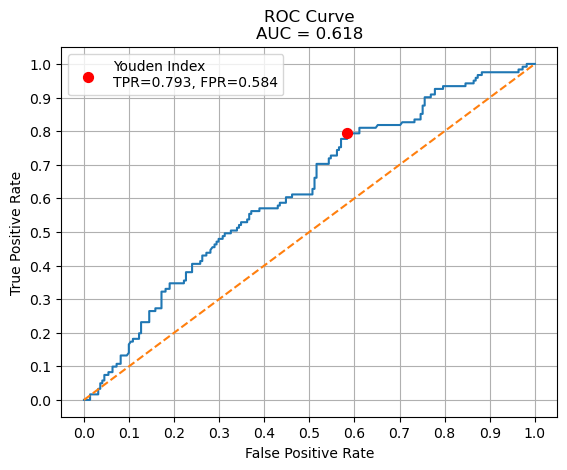

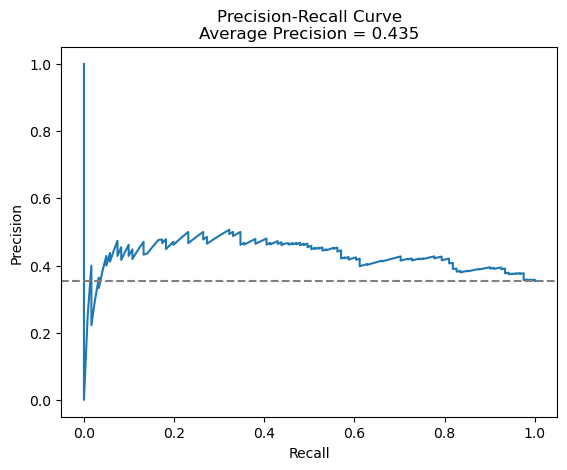

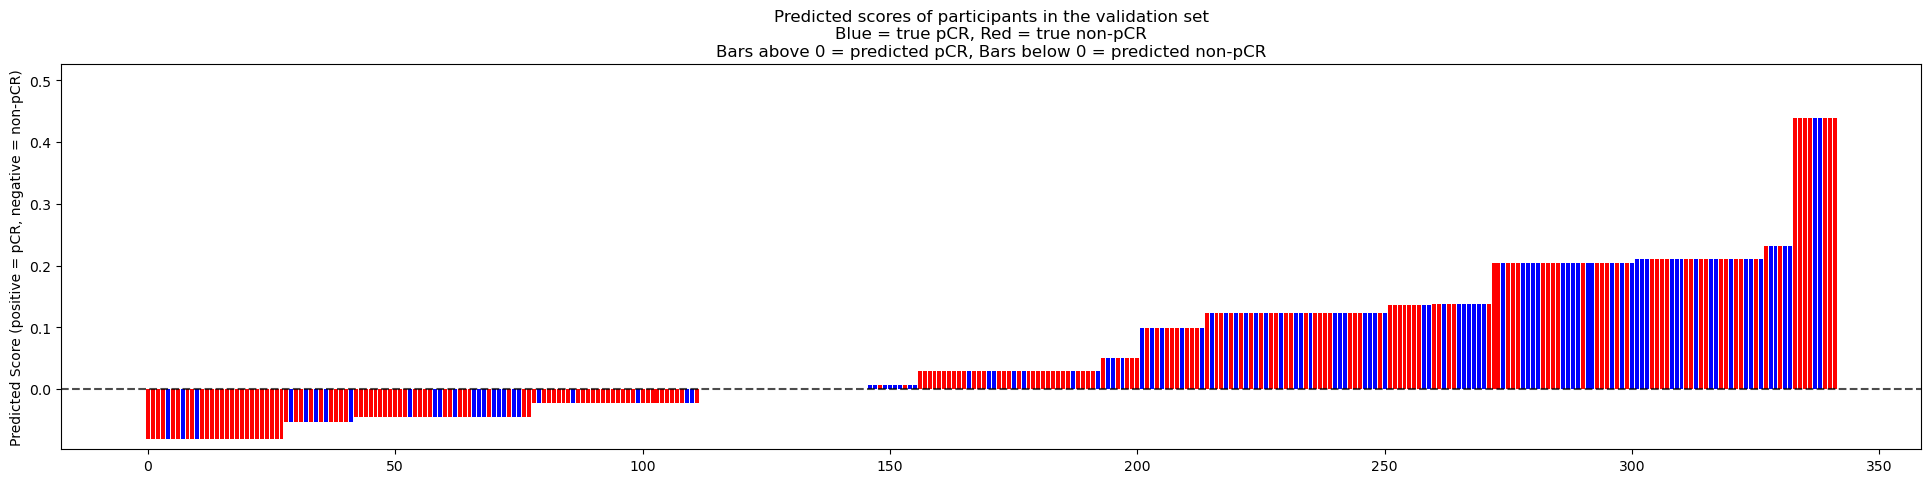

In [10]:
from models.MaxViTwithCAFusion import Model as MaxViTwithCAF

model = MaxViTwithCAF(
    partition_size=(1, 4, 4),
    downsample_depth_schedule=[True, True, False, False],
    fusion_feedforward_dim=256,
    mols_dim=32,
    hidden_fusion_dim=64,
).to(device)

'''
trainedModel = getTrainedModel(
    model,
    combine_timepoints=False,
    out_features=1,
    loss_fn=torch.nn.BCEWithLogitsLoss(),
    trainKwargs={"mode": "both"},
    testKwargs={"mode": "preNac"},
    save = True,
    filename = "MaxViTwithCAF_weights.pt"
)'''

all_y_true = []
all_y_score = []
stacked_y_true = []
stacked_y_score = []
for i, (train_index,val_index) in enumerate(skf.split(train_df,train_df["pCR"])):
    model.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH,f"MaxViTwithCAFusion_fold_{i}.pt")))
    fold_test_df = train_df.iloc[val_index]
    fold_test_dataset = ModelDataset(fold_test_df,DATASET_PATH,loading_bar=True)
    fold_test_loader = DataLoader(fold_test_dataset,batch_size=8)
    y_true, y_score = get_scores(model,fold_test_loader,combine_timepoints=False,out_features=1,mode="preNac")
    all_y_true+=y_true
    all_y_score += y_score
    stacked_y_true.append(y_true)
    stacked_y_score.append(y_score)
    
plot(all_y_true,all_y_score)
print(evalModel(stacked_y_true,stacked_y_score))

### MaxViT with Cross Attention Fusion trained on preNac only
|      |   ROC AUC |   Average Precision Score |   Sensitivity / Recall / TPR |   Specificity / TNR |   PPV / Precision |      NPV |   Accuracy |
|:-----|----------:|--------------------------:|-----------------------------:|--------------------:|------------------:|---------:|-----------:|
| 0    | 0.744345  |                  0.622861 |                     0.666667 |            0.732143 |          0.571429 | 0.803922 |   0.709302 |
| 1    | 0.544282  |                  0.378534 |                     1        |            0.163636 |          0.402597 | 1        |   0.465116 |
| 2    | 0.710303  |                  0.567305 |                     0.6      |            0.763636 |          0.580645 | 0.777778 |   0.705882 |
| 3    | 0.738788  |                  0.639599 |                     0.633333 |            0.818182 |          0.655172 | 0.803571 |   0.752941 |
| mean | 0.684429  |                  0.552075 |                     0.725    |            0.619399 |          0.552461 | 0.846318 |   0.658311 |
| std  | 0.0946143 |                  0.119749 |                     0.185343 |            0.305914 |          0.106713 | 0.103184 |   0.130566 |

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:44<00:00,  1.92it/s]


Dataset initialised with 86 entries.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:37<00:00,  2.31it/s]


Dataset initialised with 86 entries.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 85/85 [00:29<00:00,  2.85it/s]


Dataset initialised with 85 entries.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 85/85 [00:29<00:00,  2.85it/s]


Dataset initialised with 85 entries.
183
|      |   ROC AUC |   Average Precision Score |   Sensitivity / Recall / TPR |   Specificity / TNR |   PPV / Precision |      NPV |   Accuracy |
|:-----|----------:|--------------------------:|-----------------------------:|--------------------:|------------------:|---------:|-----------:|
| 0    | 0.744345  |                  0.622861 |                     0.666667 |            0.732143 |          0.571429 | 0.803922 |   0.709302 |
| 1    | 0.544282  |                  0.378534 |                     1        |            0.163636 |          0.402597 | 1        |   0.465116 |
| 2    | 0.710303  |                  0.567305 |                     0.6      |            0.763636 |          0.580645 | 0.777778 |   0.705882 |
| 3    | 0.738788  |                  0.639599 |                     0.633333 |            0.818182 |          0.655172 | 0.803571 |   0.752941 |
| mean | 0.684429  |                  0.552075 |                     0.725    |    

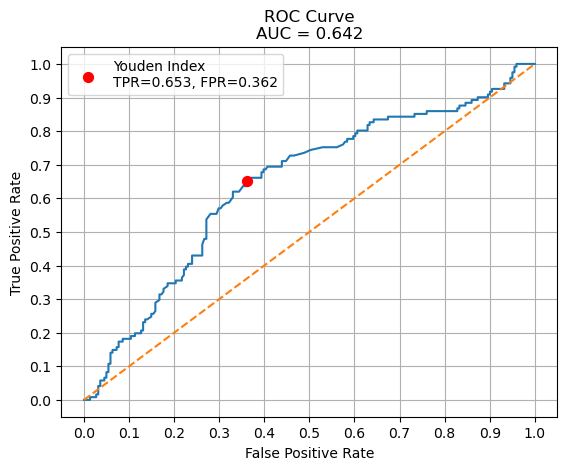

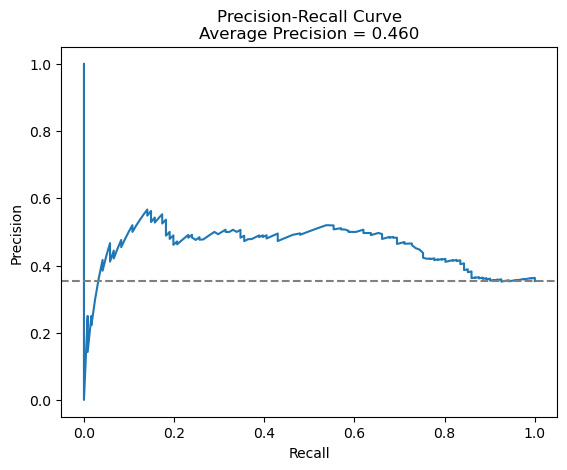

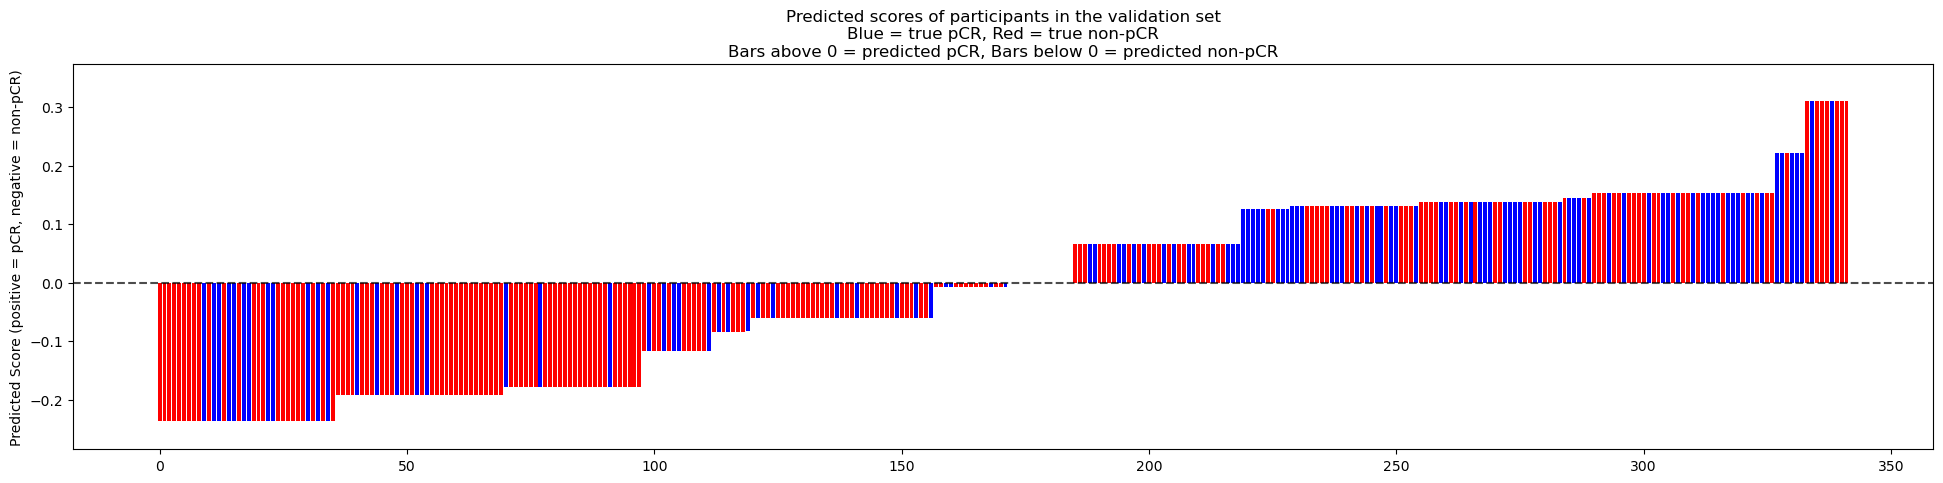

In [9]:
from models.MaxViTwithCAFusion import Model as MaxViTwithCAF

model = MaxViTwithCAF(
    partition_size=(1, 4, 4),
    downsample_depth_schedule=[True, True, False, False],
    fusion_feedforward_dim=256,
    mols_dim=32,
    hidden_fusion_dim=64,
).to(device)

'''
trainedModel = getTrainedModel(
    model,
    combine_timepoints=False,
    out_features=1,
    loss_fn=torch.nn.BCEWithLogitsLoss(),
    trainKwargs={"mode": "both"},
    testKwargs={"mode": "preNac"},
    save = True,
    filename = "MaxViTwithCAF_weights.pt"
)'''

all_y_true = []
all_y_score = []
stacked_y_true = []
stacked_y_score = []
for i, (train_index,val_index) in enumerate(skf.split(train_df,train_df["pCR"])):
    model.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH,f"MaxViTwithCAFusion_preNac_fold_{i}.pt")))
    fold_test_df = train_df.iloc[val_index]
    fold_test_dataset = ModelDataset(fold_test_df,DATASET_PATH,loading_bar=True)
    fold_test_loader = DataLoader(fold_test_dataset,batch_size=8)
    y_true, y_score = get_scores(model,fold_test_loader,combine_timepoints=False,out_features=1,mode="preNac")
    all_y_true+=y_true
    all_y_score += y_score
    stacked_y_true.append(y_true)
    stacked_y_score.append(y_score)
    
plot(all_y_true,all_y_score)
print(evalModel(stacked_y_true,stacked_y_score))

### CMC
|      |   ROC AUC |   Average Precision Score |   Sensitivity / Recall / TPR |   Specificity / TNR |   PPV / Precision |      NPV |   Accuracy |
|:-----|----------:|--------------------------:|-----------------------------:|--------------------:|------------------:|---------:|-----------:|
| 0    | 0.556548  |                0.415958   |                     0.466667 |            0.696429 |         0.451613  | 0.709091 |  0.616279  |
| 1    | 0.529619  |                0.417369   |                     0.258065 |            0.872727 |         0.533333  | 0.676056 |  0.651163  |
| 2    | 0.580606  |                0.432376   |                     0.3      |            0.872727 |         0.5625    | 0.695652 |  0.670588  |
| 3    | 0.587273  |                0.434639   |                     0.833333 |            0.345455 |         0.409836  | 0.791667 |  0.517647  |
| mean | 0.563511  |                0.425085   |                     0.464516 |            0.696834 |         0.489321  | 0.718117 |  0.613919  |
| std  | 0.0261663 |                0.00978569 |                     0.261864 |            0.248559 |         0.0707861 | 0.050875 |  0.0680009 |

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:36<00:00,  2.34it/s]


Dataset initialised with 86 entries.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:32<00:00,  2.66it/s]


Dataset initialised with 86 entries.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 85/85 [00:34<00:00,  2.46it/s]


Dataset initialised with 85 entries.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 85/85 [00:25<00:00,  3.32it/s]


Dataset initialised with 85 entries.
223
|      |   ROC AUC |   Average Precision Score |   Sensitivity / Recall / TPR |   Specificity / TNR |   PPV / Precision |      NPV |   Accuracy |
|:-----|----------:|--------------------------:|-----------------------------:|--------------------:|------------------:|---------:|-----------:|
| 0    | 0.556548  |                0.415958   |                     0.466667 |            0.696429 |         0.451613  | 0.709091 |  0.616279  |
| 1    | 0.529619  |                0.417369   |                     0.258065 |            0.872727 |         0.533333  | 0.676056 |  0.651163  |
| 2    | 0.580606  |                0.432376   |                     0.3      |            0.872727 |         0.5625    | 0.695652 |  0.670588  |
| 3    | 0.587273  |                0.434639   |                     0.833333 |            0.345455 |         0.409836  | 0.791667 |  0.517647  |
| mean | 0.563511  |                0.425085   |                     0.464516 |    

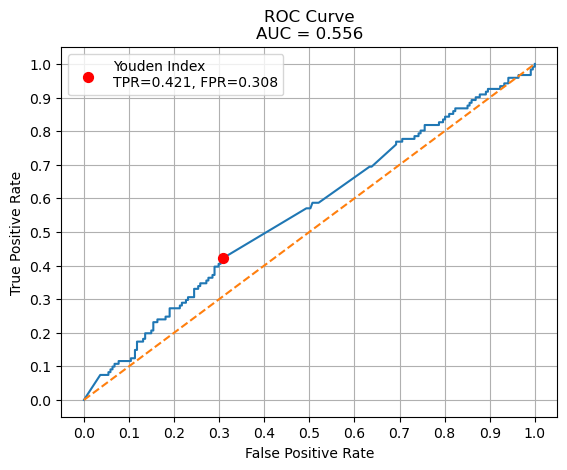

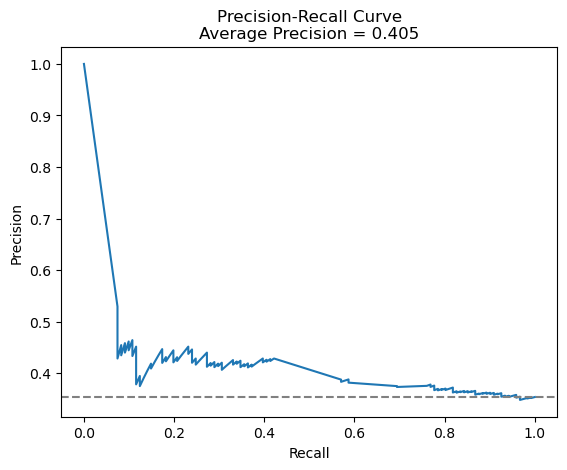

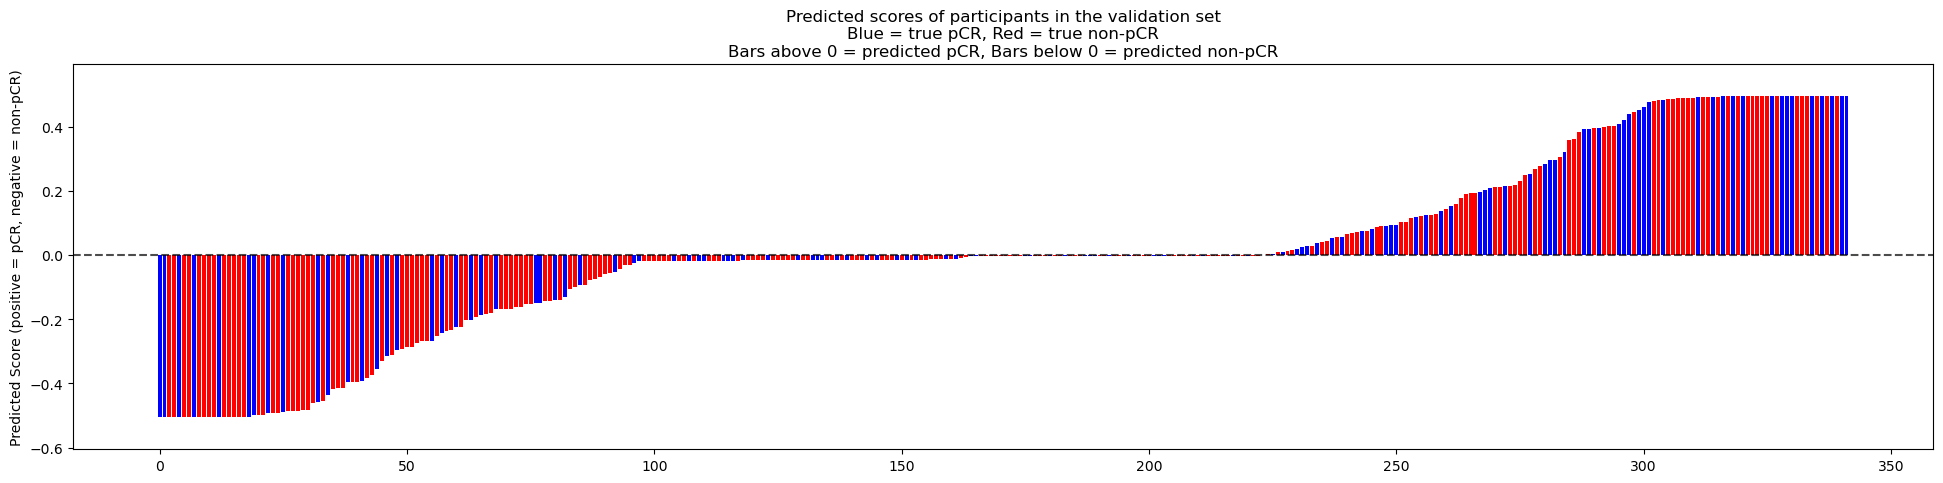

In [12]:
from models.CMC_Model.model import Model as CMCModel

model = CMCModel().to(device)

all_y_true = []
all_y_score = []
stacked_y_true = []
stacked_y_score = []
for i, (train_index,val_index) in enumerate(skf.split(train_df,train_df["pCR"])):
    model.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH,f"CMC_vanilla_fold_{i}.pt")))
    fold_test_df = train_df.iloc[val_index]
    fold_test_dataset = ModelDataset(fold_test_df,DATASET_PATH,loading_bar=True)
    fold_test_loader = DataLoader(fold_test_dataset,batch_size=8)
    y_true, y_score = get_scores(model,fold_test_loader,combine_timepoints=True,out_features=2,mode="preNac")
    all_y_true+=y_true
    all_y_score += y_score
    stacked_y_true.append(y_true)
    stacked_y_score.append(y_score)
    
plot(all_y_true,all_y_score)
print(evalModel(stacked_y_true,stacked_y_score))